In [1]:
import functools
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from joblib import Parallel, delayed
from scipy.stats import wilcoxon
from tqdm.auto import tqdm

sys.path.insert(0, str((Path(".").resolve().parent / "shared")))
sys.path.insert(0, str(Path(".").resolve()))

from obs_reconstruction import make_obs_reconstruction_figure, run_trial
from pgf_utils import (
    configure_pgf,
    configure_screen,
    figure_inches,
    save_caption,
    save_pgf,
)

In [2]:
# ── experiment constants ───────────────────────────────────────────────────────
N_TEST_SEEDS    = 50    # trials; seeds 10…59 (avoids training seeds 0–2)
FIRST_TEST_SEED = 10
T_TEST   = 2000         # timesteps per trial
T_BURNIN = 500          # burn-in before recording
T_SKIP   = 100          # discard Kalman transient before scoring R²

ERA_PATH    = Path("../../data/era_matrices.npz")
CVA_EM_PATH = Path("../../data/cva_em_matrices.npz")
FIGURES_PATH  = Path("../../figures")
CAPTIONS_PATH = Path("../../captions")

NOTEBOOK_GITHUB_URL = (
    "https://github.com/tahmidazam/gg4/blob/main/notebooks/"
    "obs_reconstruction/obs_reconstruction.ipynb"
)

In [3]:
# ── load identified model matrices ────────────────────────────────────────────
_era = np.load(ERA_PATH)
A_ERA, B_ERA, C_ERA = _era["A"], _era["B"], _era["C"]
Q_ERA, R_ERA = _era["Q"], _era["R"]

_cva = np.load(CVA_EM_PATH)
A_CVA, B_CVA, C_CVA = _cva["A"], _cva["B"], _cva["C"]
Q_CVA, R_CVA = _cva["Q"], _cva["R"]

TEST_SEEDS = list(range(FIRST_TEST_SEED, FIRST_TEST_SEED + N_TEST_SEEDS))

print(f"ERA    spectral radius: {np.max(np.abs(np.linalg.eigvals(A_ERA))):.4f}")
print(f"CVA+EM spectral radius: {np.max(np.abs(np.linalg.eigvals(A_CVA))):.4f}")
print(f"Test seeds: {TEST_SEEDS[0]}–{TEST_SEEDS[-1]}  (N = {N_TEST_SEEDS})")

ERA    spectral radius: 0.9661
CVA+EM spectral radius: 0.9408
Test seeds: 10–59  (N = 50)


In [4]:
# ── run trials in parallel ────────────────────────────────────────────────────
_run = functools.partial(
    run_trial,
    n_steps=T_TEST,
    n_burnin=T_BURNIN,
    A_era=A_ERA, B_era=B_ERA, C_era=C_ERA, Q_era=Q_ERA, R_era=R_ERA,
    A_cva=A_CVA, B_cva=B_CVA, C_cva=C_CVA, Q_cva=Q_CVA, R_cva=R_CVA,
    t_skip=T_SKIP,
)

raw_results: list = [None] * N_TEST_SEEDS
with tqdm(total=N_TEST_SEEDS, desc="Test trials") as pbar:
    for i, res in enumerate(
        Parallel(n_jobs=-1, return_as="generator_unordered")(
            delayed(_run)(seed) for seed in TEST_SEEDS
        )
    ):
        raw_results[i] = res
        pbar.update(1)
        pbar.set_postfix(completed=i + 1)

r2_era_all  = np.stack([r[0] for r in raw_results])   # (N, n_y)
r2_cva_all  = np.stack([r[1] for r in raw_results])   # (N, n_y)
r2f_era_all = np.array([r[2] for r in raw_results])   # (N,)
r2f_cva_all = np.array([r[3] for r in raw_results])   # (N,)

data = dict(
    r2_era=r2_era_all,
    r2_cva=r2_cva_all,
    r2f_era=r2f_era_all,
    r2f_cva=r2f_cva_all,
)

# ── critical metrics ──────────────────────────────────────────────────────────
era_median  = float(np.median(r2_era_all))
cva_median  = float(np.median(r2_cva_all))
eraf_median = float(np.median(r2f_era_all))
cvaf_median = float(np.median(r2f_cva_all))

# Paired Wilcoxon on per-trial Frobenius R²
w_stat, p_value = wilcoxon(r2f_era_all, r2f_cva_all, alternative="greater")

print(f"ERA    per-channel median R²  = {era_median:.4f}")
print(f"CVA+EM per-channel median R²  = {cva_median:.4f}")
print(f"ERA    Frobenius median R²_F  = {eraf_median:.4f}")
print(f"CVA+EM Frobenius median R²_F  = {cvaf_median:.4f}")
print(f"Wilcoxon signed-rank (ERA > CVA+EM, R²_F):  W = {w_stat:.1f},  p = {p_value:.4e}")
print()
print("Expected: ERA medians higher than CVA+EM; p < 0.05.")

Test trials:   0%|          | 0/50 [00:00<?, ?it/s]

ERA    per-channel median R²  = 0.3094
CVA+EM per-channel median R²  = 0.3992
ERA    Frobenius median R²_F  = 0.2892
CVA+EM Frobenius median R²_F  = 0.3986
Wilcoxon signed-rank (ERA > CVA+EM, R²_F):  W = 0.0,  p = 1.0000e+00

Expected: ERA medians higher than CVA+EM; p < 0.05.


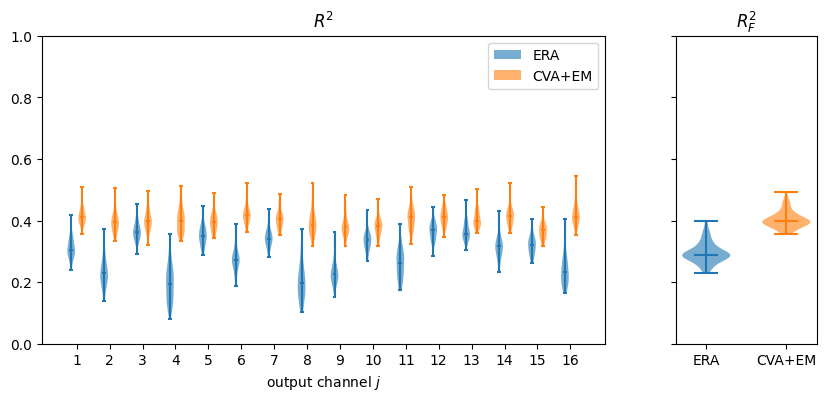

In [5]:
# ── display ────────────────────────────────────────────────────────────────────
configure_screen()
fig = make_obs_reconstruction_figure(data, figsize=(10, 4))
plt.show()

In [6]:
# ── pgf export ─────────────────────────────────────────────────────────────────
FIG_WIDTH_FRAC  = 1.0
FIG_HEIGHT_FRAC = 0.2

configure_pgf()
fig = make_obs_reconstruction_figure(
    data, figsize=figure_inches(FIG_WIDTH_FRAC, FIG_HEIGHT_FRAC)
)
save_pgf(fig, FIGURES_PATH / "obs_reconstruction.pgf")
plt.close(fig)

Saved to /Users/tahmidazam/Developer/gg4/figures/obs_reconstruction.pgf


In [7]:
# ── caption ────────────────────────────────────────────────────────────────────
n_y = r2_era_all.shape[1]

caption = (
    rf"Per-channel $R^2$ (left, $n_y = {n_y}$) and Frobenius $R^2_F$ (right) "
    rf"of one-step-ahead Kalman predictions across $N = {N_TEST_SEEDS}$ held-out trials "
    rf"of $T = {T_TEST}$ steps ($n_x = 6$; first {T_SKIP} steps excluded). "
    rf"ERA median $R^2_F = {eraf_median:.3f}$; "
    rf"CVA+EM median $R^2_F = {cvaf_median:.3f}$ "
    rf"(Wilcoxon signed-rank, $p = {p_value:.2e}$)."
)

save_caption(CAPTIONS_PATH / "obs_reconstruction.tex", caption, NOTEBOOK_GITHUB_URL)
print(caption)

Saved caption to /Users/tahmidazam/Developer/gg4/captions/obs_reconstruction.tex
Per-channel $R^2$ (left, $n_y = 16$) and Frobenius $R^2_F$ (right) of one-step-ahead Kalman predictions across $N = 50$ held-out trials of $T = 2000$ steps ($n_x = 6$; first 100 steps excluded). ERA median $R^2_F = 0.289$; CVA+EM median $R^2_F = 0.399$ (Wilcoxon signed-rank, $p = 1.00e+00$).
